In [ ]:
%pip install rdrobust rddensity statsmodels pandas numpy matplotlib rpy2

In [1]:
# Import Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
# RD packages (Python)
from rdrobust import rdplot, rdrobust

# Regression
import statsmodels.formula.api as smf
import statsmodels.api as sm

# R interface
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri, r
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import default_converter
from rpy2.robjects import pandas2ri
from sklearn.neighbors import NearestNeighbors

# Convenience alias
R = ro.r

pd.set_option("display.max_columns", 10)
pd.set_option("display.width", 1000)

In [2]:
try:
    from rdrobust import rdrobust
    rd_available = True
except ImportError:
    rd_available = False

print("rdrobust available?", rd_available)

rdrobust available? True


In [3]:
data_2010 = pd.read_csv("Data/output/data-2010.csv")
data_2010.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106999 entries, 0 to 106998
Columns: 106 entries, contractid to year_bench
dtypes: float64(86), int64(3), object(17)
memory usage: 86.5+ MB


In [4]:
data_2011 = pd.read_csv("Data/output/data-2011.csv")
data_2011.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66544 entries, 0 to 66543
Columns: 110 entries, contractid to year_bench
dtypes: float64(90), int64(3), object(17)
memory usage: 55.8+ MB


In [5]:
data_2012 = pd.read_csv("Data/output/data-2012.csv")
data_2012.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65891 entries, 0 to 65890
Columns: 111 entries, contractid to year_bench
dtypes: float64(84), int64(3), object(24)
memory usage: 55.8+ MB


In [6]:
data_2013 = pd.read_csv("Data/output/data-2013.csv")
data_2013.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66067 entries, 0 to 66066
Columns: 112 entries, contractid to year_bench
dtypes: float64(85), int64(3), object(24)
memory usage: 56.5+ MB


In [7]:
data_2014 = pd.read_csv("Data/output/data-2014.csv")
data_2014.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60497 entries, 0 to 60496
Columns: 110 entries, contractid to year_bench
dtypes: float64(83), int64(3), object(24)
memory usage: 50.8+ MB


In [8]:
data_2015 = pd.read_csv("Data/output/data-2015.csv")
data_2015.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63626 entries, 0 to 63625
Columns: 107 entries, contractid to year_bench
dtypes: float64(82), int64(4), object(21)
memory usage: 51.9+ MB


In [9]:
data_2010["year"] = 2010
data_2011["year"] = 2011
data_2012["year"] = 2012
data_2013["year"] = 2013
data_2014["year"] = 2014
data_2015["year"] = 2015

In [10]:
data = pd.concat([data_2010, data_2011, data_2012, data_2013, data_2014, data_2015], ignore_index=True)
print(list(data.columns))

['contractid', 'planid', 'fips', 'year_x', 'n_nonmiss', 'avg_enrollment', 'first_enrollment', 'last_enrollment', 'state', 'county', 'org_type', 'plan_type', 'partd', 'snp', 'eghp', 'org_name', 'org_marketing_name', 'plan_name', 'parent_org', 'contract_date', 'state_long', 'county_long', 'year_pen', 'n_elig', 'n_enrol', 'avg_eligibles', 'first_eligibles', 'last_eligibles', 'avg_enrolled', 'sd_enrolled', 'min_enrolled', 'max_enrolled', 'first_enrolled', 'last_enrolled', 'ssa', 'state_name', 'state_land', 'premium', 'premium_partc', 'premium_partd_basic', 'premium_partd_supp', 'premium_partd_total', 'partd_deductible', 'year_land', 'riskscore_partc', 'payment_partc', 'rebate_partc', 'year_y', 'payment_partd', 'directsubsidy_partd', 'reinsurance_partd', 'costsharing_partd', 'riskscore_partd', 'basic_premium', 'bid', 'breastcancer_screen', 'rectalcancer_screen', 'cv_diab_cholscreen', 'glaucoma_test', 'monitoring', 'flu_vaccine', 'pn_vaccine', 'physical_health', 'mental_health', 'osteo_test'

## Question 1

In [11]:
question_1 = data.copy()
question_1["Star_Rating"] = pd.to_numeric(question_1["Star_Rating"], errors="coerce")

# Create plan-ear
plan_year = (
    question_1.groupby(["year", "contractid", "planid", "fips"], as_index=False)
     .agg(
         star_rating=("Star_Rating", "first"),
         enrollments=("avg_enrollment", "first"),
         enrolled=("avg_enrolled", "first"),
     )
     .dropna(subset=["enrollments"])
)

# Calculate market share 
plan_year["market_share"] = (
    plan_year["enrollments"] /
    plan_year.groupby(["year", "fips"])["enrolled"].transform("first")
)


# Summary Table
summary_stats = (
    plan_year.groupby("year", as_index=False)
            .agg(
                mean_star_rating=("star_rating", "mean"),
                mean_enrollments=("enrollments", "mean"),
                mean_market_share=("market_share", "mean"),
                num_plans=("planid", "size")
            )
)

summary_stats["mean_market_share"] = 100 * summary_stats["mean_market_share"]
summary_stats.round(2)

,year,mean_star_rating,mean_enrollments,mean_market_share,num_plans
0,2010,3.08,256.90,6.59,30432
1,2011,3.30,343.67,8.57,24124
2,2012,3.42,377.68,8.58,24231
3,2013,3.58,395.93,8.17,25145
4,2014,3.76,436.87,8.02,24574
5,2015,3.90,470.17,7.89,24795


## Question 2

In [12]:
question_2 = plan_year[plan_year["star_rating"].isna()].copy()
summary_stats2 = (
    question_2.groupby("year", as_index=False)
            .agg(
                mean_enrollments=("enrollments", "mean"),
                mean_market_share=("market_share", "mean"),
                num_plans=("planid", "size")
            )
)

summary_stats2["mean_market_share"] = 100 * summary_stats2["mean_market_share"]
summary_stats2

,year,mean_enrollments,mean_market_share,num_plans
0,2010,107.394042,6.756824,11509
1,2011,167.805038,9.035681,4923
2,2012,157.238366,5.263429,3086
3,2013,160.276152,4.679610,1097
4,2014,204.829016,4.198335,1458
5,2015,314.740601,4.071184,1893


## Question 3

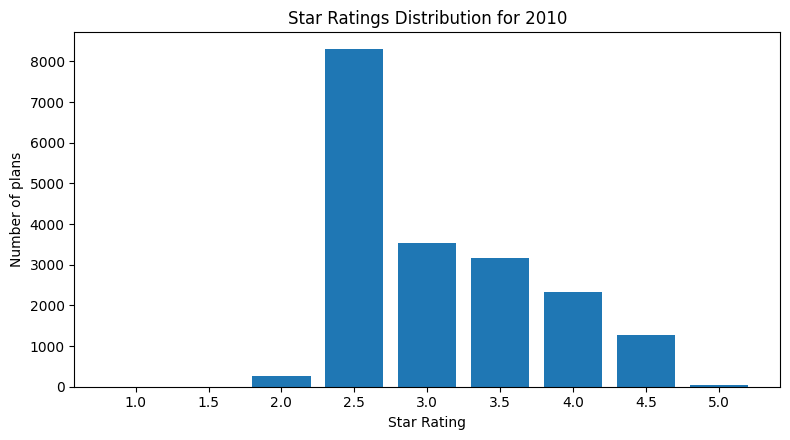

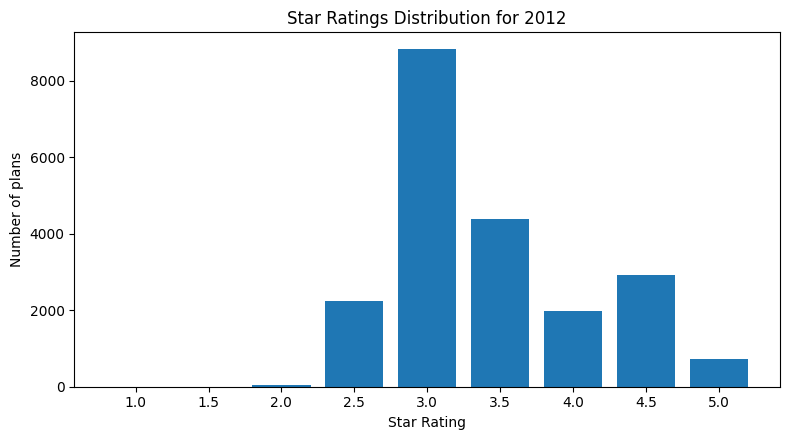

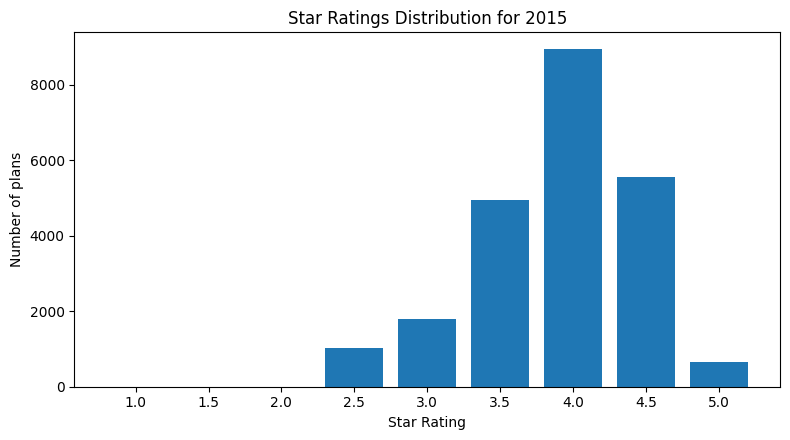

In [13]:
# Plot star rating distributions 
def plot_star_dist(df, year):
    s = df.loc[df["year"] == year, "star_rating"].dropna()

    bins = np.arange(1.0, 5.5 + 0.5, 0.5)
    labels = [f"{b:.1f}" for b in np.arange(1.0, 5.0 + 0.5, 0.5)]
    binned = pd.cut(s, bins=bins, right=False, include_lowest=True, labels=labels)
    counts = binned.value_counts().reindex(labels, fill_value=0)

    plt.figure(figsize=(8, 4.5))
    plt.bar(counts.index.astype(str), counts.values)
    plt.title(f"Star Ratings Distribution for {year}")
    plt.xlabel("Star Rating")
    plt.ylabel("Number of plans")
    plt.tight_layout()
    plt.show()

    return counts

for y in [2010, 2012, 2015]:
    plot_star_dist(plan_year, y)

The star ratings have shifted to the right overtime, as plans become higher rated. The data is now centered around 4.0 stars when it used to be greatest at 2.5 and then 3.0. 

## Question 4

In [14]:
# Create raw star ratings 
RATING_VARS = {
    2008: [
        "breastcancer_screen",
        "rectalcancer_screen",
        "cv_cholscreen",
        "diabetes_cholscreen",
        "glaucoma_test",
        "monitoring",
        "flu_vaccine",
        "pn_vaccine",
        "primaryaccess",
        "hospital_followup",
        "depression_followup",
        "nodelays",
        "carequickly",
        "overallrating_care",
        "overallrating_plan",
        "calltime",
        "doctor_communicate",
        "osteo_manage",
        "diabetes_eye",
        "diabetes_kidney",
        "diabetes_bloodsugar",
        "diabetes_chol",
        "antidepressant",
        "bloodpressure",
        "ra_manage",
        "copd_test",
        "betablocker",
        "appeals_timely",
        "appeals_review",
    ],
    2009: [
        "contractid",
        "org_type",
        "contract_name",
        "org_marketing",
        "breastcancer_screen",
        "rectalcancer_screen",
        "cv_cholscreen",
        "diabetes_cholscreen",
        "glaucoma_test",
        "monitoring",
        "flu_vaccine",
        "pn_vaccine",
        "physical_health",
        "mental_health",
        "osteo_test",
        "physical_monitor",
        "primaryaccess",
        "hospital_followup",
        "depression_followup",
        "nodelays",
        "carequickly",
        "overallrating_care",
        "overallrating_plan",
        "calltime",
        "doctor_communicate",
        "customer_service",
        "osteo_manage",
        "diabetes_eye",
        "diabetes_kidney",
        "diabetes_bloodsugar",
        "diabetes_chol",
        "antidepressant",
        "bloodpressure",
        "ra_manage",
        "copd_test",
        "betablocker",
        "bladder",
        "falling",
        "appeals_timely",
        "appeals_review",
    ],
    2010: [
        "breastcancer_screen",
        "rectalcancer_screen",
        "cv_diab_cholscreen",
        "glaucoma_test",
        "monitoring",
        "flu_vaccine",
        "pn_vaccine",
        "physical_health",
        "mental_health",
        "osteo_test",
        "physical_monitor",
        "primaryaccess",
        "osteo_manage",
        "diab_healthy",
        "bloodpressure",
        "ra_manage",
        "copd_test",
        "bladder",
        "falling",
        "nodelays",
        "doctor_communicate",
        "carequickly",
        "customer_service",
        "overallrating_care",
        "overallrating_plan",
        "complaints_plan",
        "appeals_timely",
        "appeals_review",
        "leave_plan",
        "audit_problems",
        "hold_times",
        "info_accuracy",
        "ttyt_available",
    ],
    2011: [
        "breastcancer_screen",
        "rectalcancer_screen",
        "cv_cholscreen",
        "diab_cholscreen",
        "glaucoma_test",
        "monitoring",
        "flu_vaccine",
        "pn_vaccine",
        "physical_health",
        "mental_health",
        "osteo_test",
        "physical_monitor",
        "primaryaccess",
        "osteo_manage",
        "diabetes_eye",
        "diabetes_kidney",
        "diabetes_bloodsugar",
        "diabetes_chol",
        "bloodpressure",
        "ra_manage",
        "copd_test",
        "bladder",
        "falling",
        "nodelays",
        "doctor_communicate",
        "carequickly",
        "customer_service",
        "overallrating_care",
        "overallrating_plan",
        "complaints_plan",
        "appeals_timely",
        "appeals_review",
        "corrective_action",
        "hold_times",
        "info_accuracy",
        "ttyt_available",
    ],
    2012: [
        "breastcancer_screen",
        "rectalcancer_screen",
        "cv_cholscreen",
        "diab_cholscreen",
        "glaucoma_test",
        "flu_vaccine",
        "pn_vaccine",
        "physical_health",
        "mental_health",
        "physical_monitor",
        "primaryaccess",
        "bmi_assess",
        "older_medication",
        "older_function",
        "older_pain",
        "osteo_manage",
        "diabetes_eye",
        "diabetes_kidney",
        "diabetes_bloodsugar",
        "diabetes_chol",
        "bloodpressure",
        "ra_manage",
        "bladder",
        "falling",
        "readmissions",
        "nodelays",
        "carequickly",
        "customer_service",
        "overallrating_care",
        "overallrating_plan",
        "complaints_plan",
        "access_problems",
        "leave_plan",
        "appeals_timely",
        "appeals_review",
        "ttyt_available",
    ],
    2013: [
        "breastcancer_screen",
        "rectalcancer_screen",
        "cv_cholscreen",
        "diab_cholscreen",
        "glaucoma_test",
        "flu_vaccine",
        "physical_health",
        "mental_health",
        "physical_monitor",
        "bmi_assess",
        "older_medication",
        "older_function",
        "older_pain",
        "osteo_manage",
        "diabetes_eye",
        "diabetes_kidney",
        "diabetes_bloodsugar",
        "diabetes_chol",
        "bloodpressure",
        "ra_manage",
        "bladder",
        "falling",
        "readmissions",
        "nodelays",
        "carequickly",
        "customer_service",
        "overallrating_care",
        "overallrating_plan",
        "coordination",
        "complaints_plan",
        "access_problems",
        "leave_plan",
        "improve",
        "appeals_timely",
        "appeals_review",
        "ttyt_available",
        "enroll_timely",
    ],
    2014: [
        "breastcancer_screen",
        "rectalcancer_screen",
        "cv_cholscreen",
        "diab_cholscreen",
        "glaucoma_test",
        "flu_vaccine",
        "physical_health",
        "mental_health",
        "physical_monitor",
        "bmi_assess",
        "older_medication",
        "older_function",
        "older_pain",
        "osteo_manage",
        "diabetes_eye",
        "diabetes_kidney",
        "diabetes_bloodsugar",
        "diabetes_chol",
        "bloodpressure",
        "ra_manage",
        "bladder",
        "falling",
        "readmissions",
        "nodelays",
        "carequickly",
        "customer_service",
        "overallrating_care",
        "overallrating_plan",
        "coordination",
        "complaints_plan",
        "access_problems",
        "leave_plan",
        "improve",
        "appeals_timely",
        "appeals_review",
        "ttyt_available",
    ],
    2015: [
        "rectalcancer_screen",
        "cv_cholscreen",
        "diab_cholscreen",
        "flu_vaccine",
        "physical_health",
        "mental_health",
        "physical_monitor",
        "bmi_assess",
        "specialneeds_manage",
        "older_medication",
        "older_function",
        "older_pain",
        "osteo_manage",
        "diabetes_eye",
        "diabetes_kidney",
        "diabetes_bloodsugar",
        "diabetes_chol",
        "bloodpressure",
        "ra_manage",
        "bladder",
        "falling",
        "readmissions",
        "nodelays",
        "carequickly",
        "customer_service",
        "overallrating_care",
        "overallrating_plan",
        "coordination",
        "complaints_plan",
        "leave_plan",
        "improve",
        "appeals_timely",
        "appeals_review",
    ],
}

DATASETS = {
    2010: data_2010,
    2011: data_2011,
    2012: data_2012,
    2013: data_2013,
    2014: data_2014,
    2015: data_2015,
}

for year, df in DATASETS.items():
    cols = [c for c in RATING_VARS[year] if c in df.columns]
    df["raw_rating"] = df[cols].mean(axis=1, skipna=True)

In [15]:
question_4 = pd.concat([data_2010, data_2011, data_2012, data_2013, data_2014, data_2015], ignore_index=True)
question_4["Star_Rating"] = pd.to_numeric(question_4["Star_Rating"], errors="coerce")

# Create plan-year
plan_year_4 = (
    question_4.groupby(["year", "contractid", "planid", "fips"], as_index=False)
     .agg(
         star_rating=("Star_Rating", "first"),
         enrollments=("avg_enrollment", "first"),
         raw_rating=("raw_rating", "first"),
         enrolled=("avg_enrolled", "first"),
     )
     .dropna(subset=["enrollments"])
)

# Calculate market share 
plan_year_4["market_share"] = (
    plan_year_4["enrollments"] /
    plan_year_4.groupby(["year", "fips"])["enrolled"].transform("first")
)

In [16]:
question_4 = plan_year_4.copy()
question_4 = question_4.dropna(subset=["year", "market_share", "star_rating"])

# Create star rating group
def rating_group(x):
    if pd.isna(x):
        return np.nan
    if x <= 2.5:
        return "<=2.5"
    elif x == 3.0:
        return "3"
    elif x == 3.5:
        return "3.5"
    elif x == 4.0:
        return "4"
    else:
        return ">=4.5"

question_4["rating_grp"] = question_4["star_rating"].apply(rating_group)

cat_order = ["<=2.5", "3", "3.5", "4", ">=4.5"]
question_4["rating_grp"] = pd.Categorical(question_4["rating_grp"], categories=cat_order, ordered=True)

In [17]:
# OLS on full sample
# question_4_include = question_4[question_4["star_rating"] > 2.5].copy()
ols_data_2010 = question_4[question_4["year"] == 2010]
ols_data_2011 = question_4[question_4["year"] == 2011]
ols_data_2012 = question_4[question_4["year"] == 2012]
ols_data_2013 = question_4[question_4["year"] == 2013]
ols_data_2014 = question_4[question_4["year"] == 2014]
ols_data_2015 = question_4[question_4["year"] == 2015]

ols_2010 = smf.ols("market_share ~ C(rating_grp, Treatment(reference='<=2.5'))", data=ols_data_2010).fit()
ols_2011 = smf.ols("market_share ~ C(rating_grp, Treatment(reference='<=2.5'))", data=ols_data_2011).fit()
ols_2012 = smf.ols("market_share ~ C(rating_grp, Treatment(reference='<=2.5'))", data=ols_data_2012).fit()
ols_2013 = smf.ols("market_share ~ C(rating_grp, Treatment(reference='<=2.5'))", data=ols_data_2013).fit()
ols_2014 = smf.ols("market_share ~ C(rating_grp, Treatment(reference='<=2.5'))", data=ols_data_2014).fit()
ols_2015 = smf.ols("market_share ~ C(rating_grp, Treatment(reference='<=2.5'))", data=ols_data_2015).fit()

In [18]:
# Plot results 
results = {
    "2010": ols_2010,
    "2011": ols_2011,
    "2012": ols_2012,
    "2013": ols_2013,
    "2014": ols_2014,
    "2015": ols_2015,
}

rows = ["Intercept", "Star=3", "Star=3.5", "Star=4", "Star>=4.5", "N", "R2"]
table = pd.DataFrame(index=rows, columns=results.keys())

p3   = "C(rating_grp, Treatment(reference='<=2.5'))[T.3]"
p35  = "C(rating_grp, Treatment(reference='<=2.5'))[T.3.5]"
p4   = "C(rating_grp, Treatment(reference='<=2.5'))[T.4]"
p45  = "C(rating_grp, Treatment(reference='<=2.5'))[T.>=4.5]"

for year, model in results.items():
    table.loc["Intercept", year] = f"{model.params.get('Intercept', float('nan')):.4f}"
    table.loc["Star=3", year]    = f"{model.params.get(p3,  float('nan')):.4f}"
    table.loc["Star=3.5", year]  = f"{model.params.get(p35, float('nan')):.4f}"
    table.loc["Star=4", year]    = f"{model.params.get(p4,  float('nan')):.4f}"
    table.loc["Star>=4.5", year] = f"{model.params.get(p45, float('nan')):.4f}"
    table.loc["N", year] = int(model.nobs)
    table.loc["R2", year] = f"{model.rsquared:.4f}"

table

,2010,2011,2012,2013,2014,2015
Intercept,0.0635,0.0703,0.0791,0.0490,0.0640,0.0606
Star=3,0.0124,0.0350,0.0307,0.0624,0.0269,0.0272
Star=3.5,0.0004,0.0192,0.0129,0.0387,0.0275,0.0389
Star=4,-0.0040,0.0026,-0.0206,0.0164,0.0097,0.0115
Star>=4.5,-0.0075,-0.0094,-0.0119,0.0253,0.0081,0.0234
N,18923,19201,21145,24048,23116,22902
R2,0.0039,0.0193,0.0213,0.0206,0.0058,0.0084


## Question 5

In [19]:
question_5 = question_4[question_4["year"] == 2010].copy()

# Keep only the star ratings requested: 3, 3.5, 4, 4.5, 5
keep = [3.0, 3.5, 4.0, 4.5, 5.0]
question_5 = question_5[question_5["star_rating"].isin(keep)].copy()

# Rounded up indicator
question_5["rounded_up"] = (question_5["raw_rating"] < question_5["star_rating"]).astype(int)

# Table: number of plans rounded up INTO each star rating
question5_table = (
    question_5.groupby("star_rating", as_index=False)
           .agg(plans_rounded_up=("rounded_up", "sum"),
                total_plans=("rounded_up", "size"))
           .sort_values("star_rating")
)

question5_table
table = (
    question_5
    .assign(flag=lambda df: df["raw_rating"] < df["star_rating"])
    .groupby("star_rating")["flag"]
    .sum()
    .rename("plans_rounded_up")
    .reset_index()
)

table

,star_rating,plans_rounded_up
0,3.0,1669
1,3.5,1758
2,4.0,2247
3,4.5,1267
4,5.0,53


## Question 6

In [20]:
question_6 = plan_year_4[plan_year_4["year"] == 2010].copy()

candidates_mask = (
    question_6["raw_rating"].notna()
    & question_6["star_rating"].isin([2.5, 3.0])
)
ma_25star_candidates = question_6.loc[candidates_mask].copy()

n_candidates_total = len(ma_25star_candidates)

# Final sample: raw_rating in the range consistent with the star score
match_mask = (
    ma_25star_candidates["raw_rating"].between(2.5, 3)
    & (
        ((ma_25star_candidates["star_rating"] == 3.0) &
         (ma_25star_candidates["raw_rating"] >= 2.75))
        |
        ((ma_25star_candidates["star_rating"] == 2.5) &
         (ma_25star_candidates["raw_rating"] < 2.75))
    )
)
ma_25star_py = ma_25star_candidates.loc[match_mask].copy()

n_25star_total_py = len(ma_25star_py)

# print("Obs with partc_score 2.5 or 3:", n_candidates_total)
# print("Obs with raw_rating in the matching range:", n_25star_total_py)


In [21]:
ma_rd1 = ma_25star_py.copy()
ma_rd1["score"] = ma_rd1["raw_rating"] - 2.75
ma_rd1["treat"] = (ma_rd1["score"] >= 0).astype(int)
ma_rd1["window1"] = ma_rd1["score"].between(-0.175, 0.175)
ma_rd1["window2"] = ma_rd1["score"].between(-0.125, 0.125)
ma_rd1["score_treat"] = ma_rd1["score"] * ma_rd1["treat"]

In [22]:
if rd_available:
    est1_py = rdrobust(
        y=ma_rd1["market_share"].values,
        x=ma_rd1["score"].values,
        c=0,
        h=0.125,
        p=1,
        kernel="uniform",
        vce="hc0",
        masspoints="off",
    )

In [23]:
# Candidates: partc_score 2.5 or 3 with non-missing raw_rating and star_rating
question_6 = plan_year_4[plan_year_4["year"] == 2010].copy()

candidates_mask_2 = (
    question_6["raw_rating"].notna()
    & question_6["star_rating"].isin([3.0, 3.5])
)
ma_25star_candidates_2 = question_6.loc[candidates_mask_2].copy()

n_candidates_total_2 = len(ma_25star_candidates_2)

# Final sample: raw_rating in the range consistent with the star score
match_mask_2 = (
    ma_25star_candidates_2["raw_rating"].between(3.0, 3.5)
    & (
        ((ma_25star_candidates_2["star_rating"] == 3.5) &
         (ma_25star_candidates_2["raw_rating"] >= 3.25))
        |
        ((ma_25star_candidates_2["star_rating"] == 3.0) &
         (ma_25star_candidates_2["raw_rating"] < 3.25))
    )
)
ma_25star_py_2 = ma_25star_candidates_2.loc[match_mask_2].copy()

n_25star_total_py_2 = len(ma_25star_py_2)

# print("Obs with partc_score 3.0 or 3.5:", n_candidates_total_2)
# print("Obs with raw_rating in the matching range:", n_25star_total_py_2)

In [24]:
ma_rd1_2 = ma_25star_py_2.copy()
ma_rd1_2["score"] = ma_rd1_2["raw_rating"] - 3.25
ma_rd1_2["treat"] = (ma_rd1_2["score"] >= 0).astype(int)
ma_rd1_2["window1"] = ma_rd1_2["score"].between(-0.175, 0.175)
ma_rd1_2["window2"] = ma_rd1_2["score"].between(-0.125, 0.125)
ma_rd1_2["score_treat"] = ma_rd1_2["score"] * ma_rd1_2["treat"]

In [25]:
if rd_available:
    est1_py_2 = rdrobust(
        y=ma_rd1_2["market_share"].values,
        x=ma_rd1_2["score"].values,
        c=0,
        h=0.125,
        p=1,
        kernel="uniform",
        vce="hc0",
        masspoints="off",
    )


In [26]:
import pandas as pd
import numpy as np

def rd_row(label, est, h=0.125):
    return {
        "Cutoff comparison": label,
        "Bandwidth (h)": h,
        "Estimate (for market_share)": float(est.coef.iloc[0, 0]),
        "SE": float(est.se.iloc[0, 0]),
        "p-value": float(est.pv.iloc[0, 0]) if isinstance(est.pv, pd.DataFrame) else float(np.asarray(est.pv).reshape(-1)[0]),
    }

results = pd.DataFrame([
    rd_row("3.0 Stars", est1_py, h=0.125),
    rd_row("3.5 Stars", est1_py_2, h=0.125),
])

results_q6 = results.copy()
results_q6

,Cutoff comparison,Bandwidth (h),Estimate (for market_share),SE,p-value
0,3.0 Stars,0.125,0.054156,0.008827,8.519870e-10
1,3.5 Stars,0.125,-0.040718,0.009999,4.655229e-05


In [27]:
def rd_ols_table_col(df, y_col, cutoff, h=0.125):
    d = df.copy()
    d["score"] = d["raw_rating"] - cutoff
    d["treat"] = (d["score"] >= 0).astype(int)
    d = d[d["score"].between(-h, h)].copy()

    d["score_treat"] = d["score"] * d["treat"]

    X = d[["treat", "score", "score_treat"]]
    X = sm.add_constant(X)  
    y = d[y_col]

    res = sm.OLS(y, X, missing="drop").fit(cov_type="HC1")

    out = {
        "(Intercept)": (res.params["const"], res.bse["const"]),
        "Rounded": (res.params["treat"], res.bse["treat"]),
        "Running Score": (res.params["score"], res.bse["score"]),
        "Rounded x Score": (res.params["score_treat"], res.bse["score_treat"]),
        "Num Obs.": (int(res.nobs), np.nan),
        "R2": (res.rsquared, np.nan),
    }
    return out

In [28]:
def make_rd_table(df_275, df_325, y_col, h=0.125):
    col_3star  = rd_ols_table_col(df_275, y_col=y_col, cutoff=2.75, h=h)
    col_35star = rd_ols_table_col(df_325, y_col=y_col, cutoff=3.25, h=h)

    rows = ["(Intercept)", "Rounded", "Running Score", "Rounded x Score", "Num Obs.", "R2"]

    table = pd.DataFrame(index=rows, columns=["3 Stars", "3.5 Stars"], dtype=object)

    for r in rows:
        a = col_3star[r]
        b = col_35star[r]

        if r in ["Num Obs.", "R2"]:
            table.loc[r, "3 Stars"]   = f"{a[0]:.0f}" if r=="Num Obs." else f"{a[0]:.3f}"
            table.loc[r, "3.5 Stars"] = f"{b[0]:.0f}" if r=="Num Obs." else f"{b[0]:.3f}"
        else:
            table.loc[r, "3 Stars"]   = f"{a[0]:.3f} ({a[1]:.3f})"
            table.loc[r, "3.5 Stars"] = f"{b[0]:.3f} ({b[1]:.3f})"
            
    return table

table5 = make_rd_table(ma_25star_py, ma_25star_py_2, y_col="market_share", h=0.125)
table5

,3 Stars,3.5 Stars
(Intercept),0.017 (0.003),0.104 (0.010)
Rounded,0.054 (0.009),-0.041 (0.010)
Running Score,-0.731 (0.040),0.426 (0.099)
Rounded x Score,0.939 (0.121),-0.477 (0.112)
Num Obs.,5292,1872
R2,0.058,0.015


## Question 7 

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rdrobust import rdrobust

bandwidths = [0.10, 0.12, 0.13, 0.14, 0.15]

def run_rd_for_bandwidths(df, label, bandwidths):
    rows = []
    for h in bandwidths:
        est = rdrobust(
            y=df["market_share"].values,
            x=df["score"].values,
            c=0,
            h=h,
            p=1,
            kernel="uniform",
            vce="hc0",
            masspoints="off",
        )

        # Your rdrobust object fields are DataFrames, so use .iloc
        rows.append({
            "cutoff": label,
            "h": h,
            "estimate": float(est.coef.iloc[0, 0]),
            "se": float(est.se.iloc[0, 0]),
            "ci_low": float(est.ci.iloc[0, 0]),
            "ci_high": float(est.ci.iloc[0, 1]),
            "p_value": float(est.pv.iloc[0, 0]),
        })
    return pd.DataFrame(rows)

res_3  = run_rd_for_bandwidths(ma_rd1.dropna(subset=["market_share","score"]),
                               "3.0 vs 2.5 (cutoff=2.75)", bandwidths)
res_35 = run_rd_for_bandwidths(ma_rd1_2.dropna(subset=["market_share","score"]),
                               "3.5 vs 3.0 (cutoff=3.25)", bandwidths)

results = pd.concat([res_3, res_35], ignore_index=True)
results

,cutoff,h,estimate,se,ci_low,ci_high,p_value
0,3.0 vs 2.5 (cutoff=2.75),0.10,0.052466,0.012181,0.028592,0.076340,1.653268e-05
1,3.0 vs 2.5 (cutoff=2.75),0.12,0.048947,0.009076,0.031158,0.066736,6.929460e-08
2,3.0 vs 2.5 (cutoff=2.75),0.13,0.058360,0.008731,0.041248,0.075473,2.321380e-11
3,3.0 vs 2.5 (cutoff=2.75),0.14,0.066364,0.008094,0.050501,0.082227,2.414881e-16
4,3.0 vs 2.5 (cutoff=2.75),0.15,0.063700,0.008089,0.047846,0.079554,3.409985e-15
5,3.5 vs 3.0 (cutoff=3.25),0.10,-0.061597,0.011416,-0.083971,-0.039222,6.825688e-08
6,3.5 vs 3.0 (cutoff=3.25),0.12,-0.040743,0.010850,-0.062008,-0.019479,1.731254e-04
7,3.5 vs 3.0 (cutoff=3.25),0.13,-0.041436,0.009880,-0.060800,-0.022071,2.742399e-05
8,3.5 vs 3.0 (cutoff=3.25),0.14,-0.047287,0.009311,-0.065536,-0.029037,3.802016e-07
9,3.5 vs 3.0 (cutoff=3.25),0.15,-0.012408,0.009301,-0.030637,0.005821,1.821675e-01


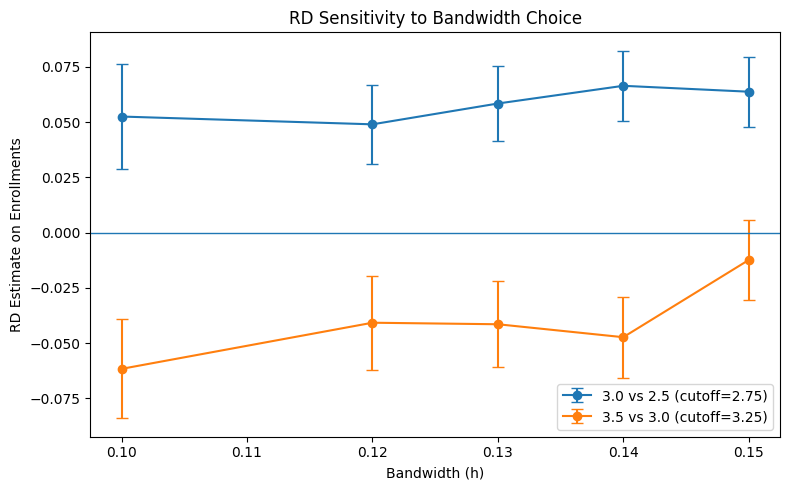

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
for cutoff, g in results.groupby("cutoff"):
    g = g.sort_values("h")
    yerr = np.vstack([g["estimate"] - g["ci_low"], g["ci_high"] - g["estimate"]])
    plt.errorbar(g["h"], g["estimate"], yerr=yerr, marker="o", capsize=4, label=cutoff)

plt.axhline(0, linewidth=1)
plt.xlabel("Bandwidth (h)")
plt.ylabel("RD Estimate on Enrollments")
plt.title("RD Sensitivity to Bandwidth Choice")
plt.legend()
plt.tight_layout()
plt.show()

The estimates are similar across the different levels of sensitivity/bandwidths. 

## Question 8

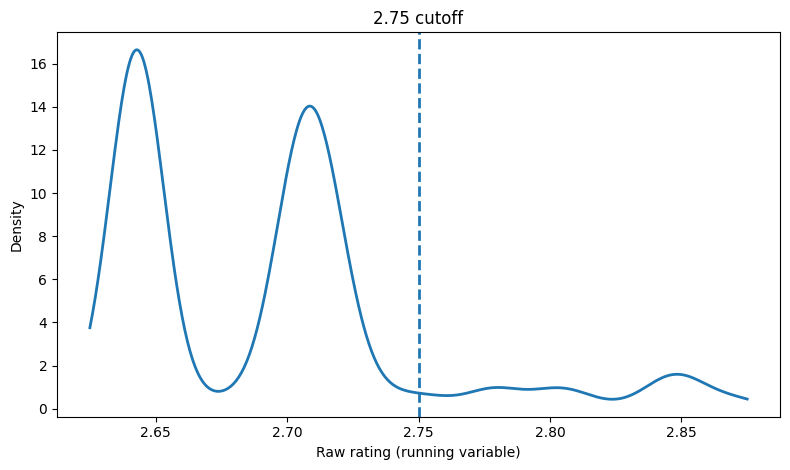

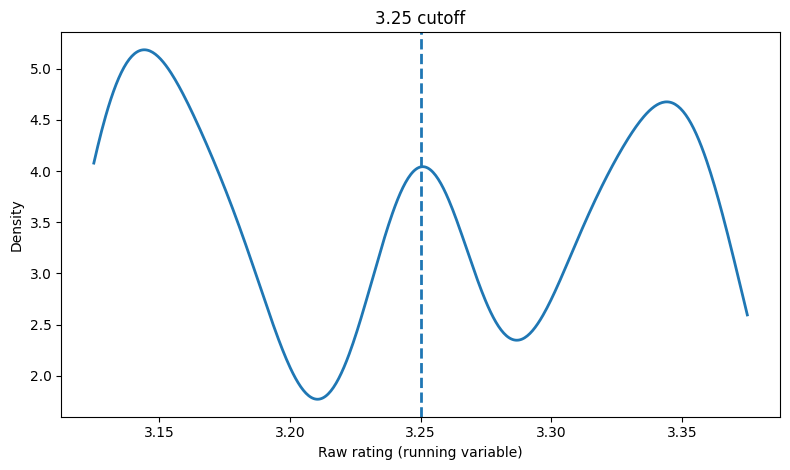

In [38]:
question_8 = question_6[question_6["star_rating"].isin([2.5, 3.0])].copy()
question_8_2 = question_6[question_6["star_rating"].isin([3.0, 3.5])].copy()

def plot_kde(df, cutoff, window=0.125, title=""):
    x = df["raw_rating"].dropna().to_numpy()
    x = x[(x >= cutoff - window) & (x <= cutoff + window)]

    xs = np.linspace(cutoff - window, cutoff + window, 500)
    kde = gaussian_kde(x)

    plt.figure(figsize=(8, 4.8))
    plt.plot(xs, kde(xs), linewidth=2)
    plt.axvline(cutoff, linestyle="--", linewidth=2)
    plt.xlabel("Raw rating (running variable)")
    plt.ylabel("Density")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_kde(question_8, cutoff=2.75, window=0.125, title="2.75 cutoff")
plot_kde(question_8_2, cutoff=3.25, window=0.125, title="3.25 cutoff")

There is a large skew in the first graph. A lot of plans with just under 2.75 raw star scores are rounded down to 2.5. There are less plans above the threshold that are rounded up. The distribution for 3.25 cutoff shows that there are not many plans just below or just above the threshold. 

## Question 9 

In [51]:
plan_year_9 = (
    data_2010.groupby(["year", "contractid", "planid", "fips"], as_index=False)
     .agg(
         star_rating=("Star_Rating", "first"),
         enrollments=("avg_enrollment", "first"),
         raw_rating=("raw_rating", "first"),
         plan_type=("plan_type", "first"),
         partd=("partd","first"),
         enrolled=("avg_enrolled", "first"),
     )
     .dropna(subset=["enrollments"])
)


plan_year_9["market_share"] = (
    plan_year_9["enrollments"] /
    plan_year_9.groupby(["year", "fips"])["enrolled"].transform("first")
)

plan_year_9["hmo_status"] = (plan_year_9["plan_type"] == "HMO/HMOPOS").astype(int)
plan_year_9["partd_status"] = (plan_year_9["partd"] == "Yes").astype(int)

In [45]:
# Candidates: partc_score 2.5 or 3 with non-missing raw_rating and star_rating
candidates_mask_9 = (
    plan_year_9["raw_rating"].notna()
    & plan_year_9["star_rating"].isin([2.5, 3.0])
)
ma_25star_candidates_9 = plan_year_9.loc[candidates_mask_9].copy()

n_candidates_total_9 = len(ma_25star_candidates_9)

# Final sample: raw_rating in the range consistent with the star score
match_mask_9 = (
    ma_25star_candidates_9["raw_rating"].between(2.5, 3.0)
    & (
        ((ma_25star_candidates_9["star_rating"] == 3.0) &
         (ma_25star_candidates_9["raw_rating"] >= 2.75))
        |
        ((ma_25star_candidates_9["star_rating"] == 2.5) &
         (ma_25star_candidates_9["raw_rating"] < 2.75))
    )
)
ma_25star_py_9 = ma_25star_candidates_9.loc[match_mask_9].copy()

n_25star_total_py_9 = len(ma_25star_py_9)

print("Obs with partc_score 2.5 or 3:", n_candidates_total_9)
print("Obs with raw_rating in the matching range:", n_25star_total_py_9)

ma_rd1_9 = ma_25star_py_9.copy()
ma_rd1_9["score"] = ma_rd1_9["raw_rating"] - 2.75
ma_rd1_9["treat"] = (ma_rd1_9["score"] >= 0).astype(int)
ma_rd1_9["window1"] = ma_rd1_9["score"].between(-0.175, 0.175)
ma_rd1_9["window2"] = ma_rd1_9["score"].between(-0.125, 0.125)
ma_rd1_9["score_treat"] = ma_rd1_9["score"] * ma_rd1_9["treat"]

star25_1_9 = smf.ols("market_share ~ score + treat", data=ma_rd1_9).fit()
star25_2_9 = smf.ols("market_share ~ score + treat", data=ma_rd1_9[ma_rd1_9["window1"]]).fit()
star25_3_9 = smf.ols("market_share ~ score + treat + score_treat", data=ma_rd1_9[ma_rd1_9["window1"]]).fit()
star25_4_9 = smf.ols("market_share ~ score + treat + score_treat", data=ma_rd1_9[ma_rd1_9["window2"]]).fit()

est1_py_9 = float(star25_1_9.params["treat"])
est2_py_9 = float(star25_2_9.params["treat"])
est3_py_9 = float(star25_3_9.params["treat"])
est4_py_9 = float(star25_4_9.params["treat"])


Obs with partc_score 2.5 or 3: 11834
Obs with raw_rating in the matching range: 6896


In [46]:
sub = ma_rd1_9[ma_rd1_9["window2"]].copy()  

covariates = ["hmo_status", "partd_status"]

# Ensure numeric 0/1
for v in covariates:
    sub[v] = pd.to_numeric(sub[v], errors="coerce")

# Table: mean just below vs just above
summary = sub.groupby("treat")[covariates].mean().T
summary.columns = ["Below cutoff (treat=0)", "Above cutoff (treat=1)"]
summary["Difference (Above - Below)"] = summary["Above cutoff (treat=1)"] - summary["Below cutoff (treat=0)"]
summary

,Below cutoff (treat=0),Above cutoff (treat=1),Difference (Above - Below)
hmo_status,0.027468,0.500000,0.472532
partd_status,0.527039,0.838608,0.311569


In [47]:
# Candidates: partc_score 2.5 or 3 with non-missing raw_rating and star_rating
candidates_mask_92 = (
    plan_year_9["raw_rating"].notna()
    & plan_year_9["star_rating"].isin([3.0, 3.5])
)
ma_25star_candidates_92 = plan_year_9.loc[candidates_mask_92].copy()

n_candidates_total_92 = len(ma_25star_candidates_92)

# Final sample: raw_rating in the range consistent with the star score
match_mask_92= (
    ma_25star_candidates_92["raw_rating"].between(3.0, 3.5)
    & (
        ((ma_25star_candidates_92["star_rating"] == 3.5) &
         (ma_25star_candidates_92["raw_rating"] >= 3.25))
        |
        ((ma_25star_candidates_92["star_rating"] == 3.0) &
         (ma_25star_candidates_92["raw_rating"] < 3.25))
    )
)
ma_25star_py_92 = ma_25star_candidates_92.loc[match_mask_92].copy()

n_25star_total_py_92 = len(ma_25star_py_92)

print("Obs with partc_score 3.0 or 3.5:", n_candidates_total_92)
print("Obs with raw_rating in the matching range:", n_25star_total_py_92)

ma_rd1_92 = ma_25star_py_92.copy()
ma_rd1_92["score"] = ma_rd1_92["raw_rating"] - 3.25
ma_rd1_92["treat"] = (ma_rd1_92["score"] >= 0).astype(int)
ma_rd1_92["window1"] = ma_rd1_92["score"].between(-0.175, 0.175)
ma_rd1_92["window2"] = ma_rd1_92["score"].between(-0.125, 0.125)
ma_rd1_92["score_treat"] = ma_rd1_92["score"] * ma_rd1_92["treat"]

star25_1_92 = smf.ols("market_share ~ score + treat", data=ma_rd1_92).fit()
star25_2_92 = smf.ols("market_share ~ score + treat", data=ma_rd1_92[ma_rd1_92["window1"]]).fit()
star25_3_92 = smf.ols("market_share ~ score + treat + score_treat", data=ma_rd1_92[ma_rd1_92["window1"]]).fit()
star25_4_92 = smf.ols("market_share ~ score + treat + score_treat", data=ma_rd1_92[ma_rd1_92["window2"]]).fit()

Obs with partc_score 3.0 or 3.5: 6708
Obs with raw_rating in the matching range: 3727


In [48]:
sub2 = ma_rd1_92[ma_rd1_92["window2"]].copy()   # or window2

covariates = ["hmo_status", "partd_status"]

# Ensure numeric 0/1
for v in covariates:
    sub2[v] = pd.to_numeric(sub2[v], errors="coerce")

# Table: mean just below vs just above
summary_2 = sub2.groupby("treat")[covariates].mean().T
summary_2.columns = ["Below cutoff (treat=0)", "Above cutoff (treat=1)"]
summary_2["Difference (Above - Below)"] = summary_2["Above cutoff (treat=1)"] - summary_2["Below cutoff (treat=0)"]
summary_2

,Below cutoff (treat=0),Above cutoff (treat=1),Difference (Above - Below)
hmo_status,0.783092,0.377184,-0.405908
partd_status,0.865406,0.843782,-0.021624


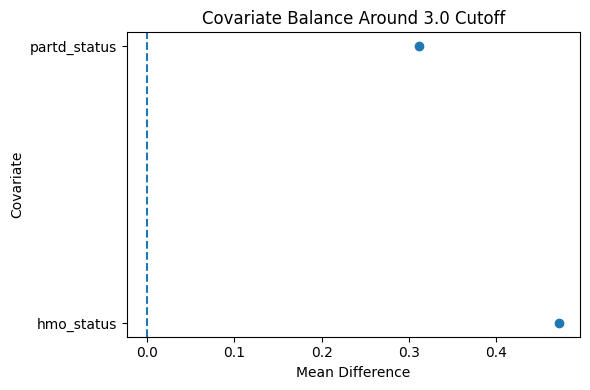

In [49]:
# Extract mean differences
diffs = summary["Difference (Above - Below)"]

plt.figure(figsize=(6,4))

# Plot dots
plt.scatter(diffs, diffs.index)

# Vertical line at zero
plt.axvline(0, linestyle="--", linewidth=1.5)

plt.xlabel("Mean Difference")
plt.ylabel("Covariate")
plt.title("Covariate Balance Around 3.0 Cutoff")

plt.tight_layout()
plt.show()

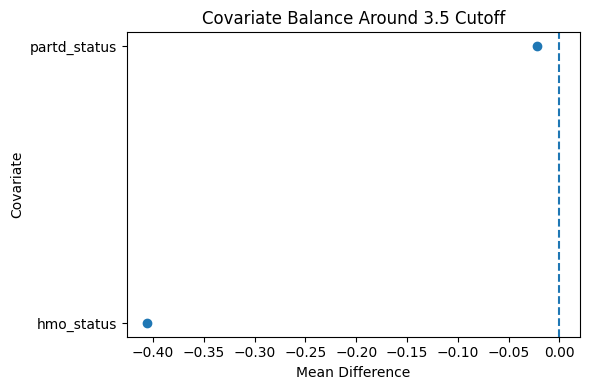

In [50]:
# Extract mean differences
diffs = summary_2["Difference (Above - Below)"]

plt.figure(figsize=(6,4))

# Plot dots
plt.scatter(diffs, diffs.index)

# Vertical line at zero
plt.axvline(0, linestyle="--", linewidth=1.5)

plt.xlabel("Mean Difference")
plt.ylabel("Covariate")
plt.title("Covariate Balance Around 3.5 Cutoff")

plt.tight_layout()
plt.show()

## Question 10

The effect of star ratings on enrollment/market share is large for the 2.5 versus 3.0 star comparison. There is a strong positive relationship between higher rating and greater enrollment. However, this difference is not as pronounced for the 3.0 versus 3.5 star comparison. Based on question 6, it appears that being 3 stars instead of 2.5 increases market share by 0.054; however, being 3.5 instead of 3.0 stars might decrease market share by 0.041. Based on question 7, these relationships appear similar across all bandwidths. However, question 9 suggests that there may be some imbalance in the covariates for the treatment groups. 